In [4]:
from pathlib import Path

In [5]:
DATA_ROOT = Path("../data/raw")


class_to_idx = {
    "walking": 0,
    "running": 1,
    "boxing": 2
}

In [6]:
from pathlib import Path

print("Dossier courant :", Path.cwd())
print("DATA_ROOT :", DATA_ROOT)
print("Existe ?", DATA_ROOT.exists())

Dossier courant : /mnt/c/Users/pc/deep_learning_pojects/video_action_recognition/notebooks
DATA_ROOT : ../data/raw
Existe ? True


In [7]:
samples = []

for class_name, label in class_to_idx.items():
    class_dir = DATA_ROOT / class_name

    for video_path in class_dir.glob("*.avi"):
        samples.append({
            "path": video_path,
            "label": label,
            "class_name": class_name
        })

print(len(samples))
print(samples[0])

300
{'path': PosixPath('../data/raw/walking/person01_walking_d1_uncomp.avi'), 'label': 0, 'class_name': 'walking'}


In [8]:
for sample in samples:
    filename = sample["path"].name
    person = filename.split("_")[0]
    sample["person"] = person

print(samples[0])

{'path': PosixPath('../data/raw/walking/person01_walking_d1_uncomp.avi'), 'label': 0, 'class_name': 'walking', 'person': 'person01'}


In [9]:
train_people = {f"person{i:02d}" for i in range(1,17)}
val_people = {f"person{i:02d}" for i in range(17,21)}
test_people = {f"person{i:02d}" for i in range(21,26)}

In [10]:
train_samples = [
    sample for sample in samples
    if sample['person'] in train_people
]

val_samples = [
    sample for sample in samples
    if sample['person'] in val_people
]

test_samples = [
    sample for sample in samples
    if sample['person'] in test_people
]

In [11]:
print("Train :", len(train_samples))
print("Val   :", len(val_samples))
print("Test  :", len(test_samples))
print("Total :", len(train_samples) + len(val_samples) + len(test_samples))

Train : 192
Val   : 48
Test  : 60
Total : 300


In [12]:
from torch.utils.data import Dataset
import cv2
import numpy as np
import torch

In [13]:
def load_video(video_path, num_frames=16, size=(112, 112)):
    cap = cv2.VideoCapture(str(video_path))

    frame_count = int(cap.get(cv2.CAP_PROP_FRAME_COUNT))

    if frame_count <= 0:
        cap.release()
        raise RuntimeError(f"Vidéo invalide : {video_path}")

    indices = np.linspace(
        0,
        frame_count - 1,
        num_frames,
        dtype=int
    )

    indices_set = set(indices.tolist())

    frames = []
    frame_idx = 0

    while True:
        ret, frame = cap.read()

        if not ret:
            break

        if frame_idx in indices_set:
            frame = cv2.cvtColor(frame, cv2.COLOR_BGR2RGB)
            frame = cv2.resize(frame, size)
            frame = torch.from_numpy(frame).permute(2, 0, 1)

            frames.append(frame)

        frame_idx += 1

    cap.release()

    if len(frames) == 0:
        raise RuntimeError(f"Impossible de lire : {video_path}")

    # sécurité si OpenCV n'a pas réussi à atteindre certaines frames
    while len(frames) < num_frames:
        frames.append(frames[-1].clone())

    frames = frames[:num_frames]

    return torch.stack(frames).float() / 255.0

In [14]:
class VideoDataset(Dataset):
    def __init__(self,samples):
        self.samples = samples

    def __len__(self):
        return len(self.samples)
    def __getitem__(self,idx):
        sample = self.samples[idx]

        X = load_video(sample['path'])
        y = sample['label']

        return X, y

In [15]:
dataset = VideoDataset(train_samples)
len(dataset)

192

In [16]:
X, y = dataset[0]

print(X.shape)
print(y)

torch.Size([16, 3, 112, 112])
0


In [17]:
from torch.utils.data import DataLoader

In [18]:
train_dataset = VideoDataset(train_samples)
val_dataset = VideoDataset(val_samples)
test_dataset = VideoDataset(test_samples)

In [19]:
train_loader = DataLoader(
    train_dataset,
    batch_size=4,
    shuffle=True,
    num_workers=2
)

val_loader = DataLoader(
    val_dataset,
    batch_size=4,
    shuffle=False,
    num_workers=2
)

test_loader = DataLoader(
    test_dataset,
    batch_size=4,
    shuffle=False,
    num_workers=2
)

In [20]:
videos, labels = next(iter(train_loader))

print("video :",videos.shape)
print("Labels :", labels.shape)
print("Labels :", labels)

video : torch.Size([4, 16, 3, 112, 112])
Labels : torch.Size([4])
Labels : tensor([2, 2, 0, 2])


In [21]:
video = videos.permute(0,2,1,3,4)

In [22]:
import torch.nn as nn

block1 = nn.Sequential(
    nn.Conv3d(
        in_channels=3,
        out_channels=8,
        kernel_size=3,
        padding=1
    ),
    nn.ReLU(),
    nn.MaxPool3d(kernel_size=(1,2,2))
)

In [23]:
class Simple3DCNN(nn.Module):
    def __init__(self, num_classes=3):
        super().__init__()

        self.features = nn.Sequential(
            nn.Conv3d(3, 8, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.MaxPool3d((1, 2, 2)),

            nn.Conv3d(8, 16, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.MaxPool3d((2, 2, 2)),

            nn.Conv3d(16, 32, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.MaxPool3d((2, 2, 2))
        )

        self.pool = nn.AdaptiveAvgPool3d((1, 1, 1))
        self.classifier = nn.Linear(32, num_classes)

    def forward(self, x):
        x = self.features(x)
        x = self.pool(x)
        x = torch.flatten(x, 1)
        x = self.classifier(x)
        return x

In [24]:
model = Simple3DCNN(num_classes=3)

videos, labels = next(iter(train_loader))
videos = videos.permute(0, 2, 1, 3, 4)

outputs = model(videos)

print("Input :", videos.shape)
print("Output:", outputs.shape)
print(outputs)

Input : torch.Size([4, 3, 16, 112, 112])
Output: torch.Size([4, 3])
tensor([[ 0.0770,  0.1551, -0.0609],
        [ 0.0672,  0.1484, -0.0650],
        [ 0.0683,  0.1497, -0.0647],
        [ 0.0774,  0.1552, -0.0602]], grad_fn=<AddmmBackward0>)


In [25]:
criterion = nn.CrossEntropyLoss()

loss = criterion(outputs, labels)

print("Label :", labels)
print("Loss :", loss.item())

Label : tensor([0, 0, 0, 0])
Loss : 1.0839797258377075


In [26]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(device)

model = Simple3DCNN(num_classes=3).to(device)

cuda


In [27]:
criterion = nn.CrossEntropyLoss()

optimizer = torch.optim.Adam(
    model.parameters(),
    lr=1e-3
)

videos, labels = next(iter(train_loader))
videos = videos.permute(0,2,1,3,4)

videos = videos.to(device)
labels = labels.to(device)
optimizer.zero_grad()
outputs = model(videos)
loss = criterion(outputs,labels)
loss.backward()
optimizer.step()

print("Loss :", loss.item())

[mpeg4 @ 0xed740c0] ac-tex damaged at 8 6
[mpeg4 @ 0xed740c0] Error at MB: 74


Loss : 1.0643980503082275


In [28]:
before = model.features[0].weight.detach().clone()

videos, labels = next(iter(train_loader))
videos = videos.permute(0, 2, 1, 3, 4).to(device)
labels = labels.to(device)

optimizer.zero_grad()
outputs = model(videos)
loss = criterion(outputs, labels)
loss.backward()
optimizer.step()

after = model.features[0].weight.detach().clone()

print("Poids modifiés :", not torch.equal(before, after))
print("Loss :", loss.item())

Poids modifiés : True
Loss : 1.121660590171814


In [29]:
print(labels.size(0))

4


In [30]:
def train_one_epoch(model, loader, criterion,optimizer,device):
    model.train()

    running_loss = 0.0
    correct = 0
    total = 0
    for videos, labels in loader:
        videos = videos.permute(0,2,1,3,4)

        videos = videos.to(device)
        labels = labels.to(device)
        optimizer.zero_grad()

        outputs = model(videos)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()

        running_loss += loss.item() * labels.size(0)

        predictions  = outputs.argmax(dim=1)

        correct += (predictions == labels).sum().item()
        total += labels.size(0)

    epoch_loss = running_loss / total
    epoch_accuracy = correct / total

    return epoch_loss, epoch_accuracy

In [31]:
def evaluate(model, loader, criterion, device):

    model.eval()
    running_loss = 0.0
    correct = 0
    total = 0

    with torch.no_grad():

        for videos, labels in loader:

            videos = videos.permute(0,2,1,3,4)
            videos = videos.to(device)
            labels = labels.to(device)

            outputs = model(videos)

            loss = criterion(outputs, labels)
            running_loss += loss.item() * labels.size(0)

            prediction = outputs.argmax(dim=1)

            correct += (prediction == labels).sum().item()
            total += labels.size(0)

        loss = running_loss / total
        accuracy = correct / total

        return loss, accuracy




In [32]:
num_epochs = 5

for epoch in range(num_epochs):

    train_loss, train_acc = train_one_epoch(
        model,
        train_loader,
        criterion,
        optimizer,
        device
    )

    val_loss, val_acc = evaluate(
        model,
        val_loader,
        criterion,
        device
    )

    print(
        f"Epoch {epoch+1}/{num_epochs} | "
        f"Train Loss: {train_loss:.4f} | "
        f"Train Acc: {train_acc:.3f} | "
        f"Val Loss: {val_loss:.4f} | "
        f"Val Acc: {val_acc:.3f}"
    )

[mpeg4 @ 0x24220740] ac-tex damaged at 8 6
[mpeg4 @ 0x24220740] Error at MB: 74


Epoch 1/5 | Train Loss: 1.1136 | Train Acc: 0.333 | Val Loss: 1.1048 | Val Acc: 0.333


[mpeg4 @ 0x2497ca80] ac-tex damaged at 8 6
[mpeg4 @ 0x2497ca80] Error at MB: 74


Epoch 2/5 | Train Loss: 1.1014 | Train Acc: 0.375 | Val Loss: 1.0906 | Val Acc: 0.500


[mpeg4 @ 0x249a5a40] ac-tex damaged at 8 6
[mpeg4 @ 0x249a5a40] Error at MB: 74


Epoch 3/5 | Train Loss: 1.0860 | Train Acc: 0.448 | Val Loss: 1.0619 | Val Acc: 0.396


[mpeg4 @ 0x24952840] ac-tex damaged at 8 6
[mpeg4 @ 0x24952840] Error at MB: 74


Epoch 4/5 | Train Loss: 1.0414 | Train Acc: 0.375 | Val Loss: 0.9768 | Val Acc: 0.333


[mpeg4 @ 0x24939ec0] ac-tex damaged at 8 6
[mpeg4 @ 0x24939ec0] Error at MB: 74


Epoch 5/5 | Train Loss: 0.9532 | Train Acc: 0.443 | Val Loss: 0.8586 | Val Acc: 0.604


On peut voir que le model n'apprend pas du tout , il y a 3 class donc de maniere dummy il dit juste 0.33

# Tester avec un petit dataset pour voir si y a overfitting

In [33]:
tiny_samples = []

for label in range(3):
    class_samples = [
        s for s in train_samples
        if s["label"] == label
    ]

    tiny_samples.extend(class_samples[:4])

print(len(tiny_samples))

for s in tiny_samples:
    print(s["class_name"], s["path"].name)

12
walking person01_walking_d1_uncomp.avi
walking person01_walking_d2_uncomp.avi
walking person01_walking_d3_uncomp.avi
walking person01_walking_d4_uncomp.avi
running person01_running_d1_uncomp.avi
running person01_running_d2_uncomp.avi
running person01_running_d3_uncomp.avi
running person01_running_d4_uncomp.avi
boxing person01_boxing_d1_uncomp.avi
boxing person01_boxing_d2_uncomp.avi
boxing person01_boxing_d3_uncomp.avi
boxing person01_boxing_d4_uncomp.avi


In [34]:
tiny_dataset = VideoDataset(tiny_samples)

tiny_loader = DataLoader(
    tiny_dataset,
    batch_size=12,
    shuffle=True,
    num_workers=0
)

model = Simple3DCNN(num_classes=3).to(device)

criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)

for epoch in range(100):

    model.train()

    videos, labels = next(iter(tiny_loader))

    videos = videos.permute(0, 2, 1, 3, 4).to(device)
    labels = labels.to(device)

    optimizer.zero_grad()

    outputs = model(videos)
    loss = criterion(outputs, labels)

    loss.backward()
    optimizer.step()

    predictions = outputs.argmax(dim=1)
    accuracy = (predictions == labels).float().mean().item()

    if (epoch + 1) % 10 == 0:
        print(
            f"Epoch {epoch+1:3d} | "
            f"Loss: {loss.item():.4f} | "
            f"Acc: {accuracy:.3f}"
        )

[mpeg4 @ 0xed3e4c0] ac-tex damaged at 8 6
[mpeg4 @ 0xed3e4c0] Error at MB: 74
[mpeg4 @ 0xed86bc0] ac-tex damaged at 8 6
[mpeg4 @ 0xed86bc0] Error at MB: 74
[mpeg4 @ 0xed86bc0] ac-tex damaged at 8 6
[mpeg4 @ 0xed86bc0] Error at MB: 74
[mpeg4 @ 0xed3e4c0] ac-tex damaged at 8 6
[mpeg4 @ 0xed3e4c0] Error at MB: 74
[mpeg4 @ 0xed04d00] ac-tex damaged at 8 6
[mpeg4 @ 0xed04d00] Error at MB: 74
[mpeg4 @ 0xed01fc0] ac-tex damaged at 8 6
[mpeg4 @ 0xed01fc0] Error at MB: 74
[mpeg4 @ 0xed07a40] ac-tex damaged at 8 6
[mpeg4 @ 0xed07a40] Error at MB: 74
[mpeg4 @ 0xed04d00] ac-tex damaged at 8 6
[mpeg4 @ 0xed04d00] Error at MB: 74
[mpeg4 @ 0xecff280] ac-tex damaged at 8 6
[mpeg4 @ 0xecff280] Error at MB: 74
[mpeg4 @ 0xed01fc0] ac-tex damaged at 8 6
[mpeg4 @ 0xed01fc0] Error at MB: 74


Epoch  10 | Loss: 1.0915 | Acc: 0.500


[mpeg4 @ 0xed01fc0] ac-tex damaged at 8 6
[mpeg4 @ 0xed01fc0] Error at MB: 74
[mpeg4 @ 0x2493a400] ac-tex damaged at 8 6
[mpeg4 @ 0x2493a400] Error at MB: 74
[mpeg4 @ 0x2493a400] ac-tex damaged at 8 6
[mpeg4 @ 0x2493a400] Error at MB: 74
[mpeg4 @ 0x2492c000] ac-tex damaged at 8 6
[mpeg4 @ 0x2492c000] Error at MB: 74
[mpeg4 @ 0xecf78c0] ac-tex damaged at 8 6
[mpeg4 @ 0xecf78c0] Error at MB: 74
[mpeg4 @ 0x24213d00] ac-tex damaged at 8 6
[mpeg4 @ 0x24213d00] Error at MB: 74
[mpeg4 @ 0xecff280] ac-tex damaged at 8 6
[mpeg4 @ 0xecff280] Error at MB: 74
[mpeg4 @ 0xed07a40] ac-tex damaged at 8 6
[mpeg4 @ 0xed07a40] Error at MB: 74
[mpeg4 @ 0xed86bc0] ac-tex damaged at 8 6
[mpeg4 @ 0xed86bc0] Error at MB: 74
[mpeg4 @ 0xed04d00] ac-tex damaged at 8 6
[mpeg4 @ 0xed04d00] Error at MB: 74


Epoch  20 | Loss: 1.0568 | Acc: 0.667


[mpeg4 @ 0xed926c0] ac-tex damaged at 8 6
[mpeg4 @ 0xed926c0] Error at MB: 74
[mpeg4 @ 0xed07a40] ac-tex damaged at 8 6
[mpeg4 @ 0xed07a40] Error at MB: 74
[mpeg4 @ 0xed07a40] ac-tex damaged at 8 6
[mpeg4 @ 0xed07a40] Error at MB: 74
[mpeg4 @ 0xed07a40] ac-tex damaged at 8 6
[mpeg4 @ 0xed07a40] Error at MB: 74
[mpeg4 @ 0x2492c000] ac-tex damaged at 8 6
[mpeg4 @ 0x2492c000] Error at MB: 74
[mpeg4 @ 0x2492c000] ac-tex damaged at 8 6
[mpeg4 @ 0x2492c000] Error at MB: 74
[mpeg4 @ 0xed926c0] ac-tex damaged at 8 6
[mpeg4 @ 0xed926c0] Error at MB: 74
[mpeg4 @ 0xed926c0] ac-tex damaged at 8 6
[mpeg4 @ 0xed926c0] Error at MB: 74
[mpeg4 @ 0xecff740] ac-tex damaged at 8 6
[mpeg4 @ 0xecff740] Error at MB: 74
[mpeg4 @ 0xed61a80] ac-tex damaged at 8 6
[mpeg4 @ 0xed61a80] Error at MB: 74


...

Epoch  80 | Loss: 0.4678 | Acc: 0.750


[mpeg4 @ 0xed3e4c0] ac-tex damaged at 8 6
[mpeg4 @ 0xed3e4c0] Error at MB: 74
[mpeg4 @ 0xed07a40] ac-tex damaged at 8 6
[mpeg4 @ 0xed07a40] Error at MB: 74
[mpeg4 @ 0x24213d00] ac-tex damaged at 8 6
[mpeg4 @ 0x24213d00] Error at MB: 74
[mpeg4 @ 0x2492c000] ac-tex damaged at 8 6
[mpeg4 @ 0x2492c000] Error at MB: 74
[mpeg4 @ 0xed926c0] ac-tex damaged at 8 6
[mpeg4 @ 0xed926c0] Error at MB: 74
[mpeg4 @ 0x2492c000] ac-tex damaged at 8 6
[mpeg4 @ 0x2492c000] Error at MB: 74
[mpeg4 @ 0xed86bc0] ac-tex damaged at 8 6
[mpeg4 @ 0xed86bc0] Error at MB: 74
[mpeg4 @ 0xed86bc0] ac-tex damaged at 8 6
[mpeg4 @ 0xed86bc0] Error at MB: 74
[mpeg4 @ 0xed926c0] ac-tex damaged at 8 6
[mpeg4 @ 0xed926c0] Error at MB: 74
[mpeg4 @ 0xed04d00] ac-tex damaged at 8 6
[mpeg4 @ 0xed04d00] Error at MB: 74


Epoch  90 | Loss: 0.4261 | Acc: 0.750


[mpeg4 @ 0xecff280] ac-tex damaged at 8 6
[mpeg4 @ 0xecff280] Error at MB: 74
[mpeg4 @ 0x2492c000] ac-tex damaged at 8 6
[mpeg4 @ 0x2492c000] Error at MB: 74
[mpeg4 @ 0xecff280] ac-tex damaged at 8 6
[mpeg4 @ 0xecff280] Error at MB: 74
[mpeg4 @ 0xed926c0] ac-tex damaged at 8 6
[mpeg4 @ 0xed926c0] Error at MB: 74
[mpeg4 @ 0x2492c000] ac-tex damaged at 8 6
[mpeg4 @ 0x2492c000] Error at MB: 74
[mpeg4 @ 0x2492c000] ac-tex damaged at 8 6
[mpeg4 @ 0x2492c000] Error at MB: 74
[mpeg4 @ 0xed04d00] ac-tex damaged at 8 6
[mpeg4 @ 0xed04d00] Error at MB: 74
[mpeg4 @ 0xed926c0] ac-tex damaged at 8 6
[mpeg4 @ 0xed926c0] Error at MB: 74
[mpeg4 @ 0xed86bc0] ac-tex damaged at 8 6
[mpeg4 @ 0xed86bc0] Error at MB: 74
[mpeg4 @ 0xed926c0] ac-tex damaged at 8 6
[mpeg4 @ 0xed926c0] Error at MB: 74


Epoch 100 | Loss: 0.3863 | Acc: 0.833


In [35]:
from pathlib import Path
import torch

PROCESSED_ROOT = Path("../data/processed")
PROCESSED_ROOT.mkdir(parents=True, exist_ok=True)

In [36]:
def preprocess_samples(samples):
    processed = []

    for i, sample in enumerate(samples):
        video = load_video(sample["path"])

        output_path = PROCESSED_ROOT / f"video_{i:04d}.pt"

        torch.save(video, output_path)

        processed.append({
            "path": output_path,
            "label": sample["label"],
            "class_name": sample["class_name"],
            "person": sample["person"]
        })

        if (i + 1) % 25 == 0:
            print(f"{i+1}/{len(samples)}")

    return processed

processed_samples = preprocess_samples(samples)

25/300
50/300
75/300
100/300
125/300
150/300
175/300
200/300


[mpeg4 @ 0xecff740] ac-tex damaged at 8 6
[mpeg4 @ 0xecff740] Error at MB: 74


225/300
250/300
275/300
300/300


In [37]:
processed_train = [
    s for s in processed_samples
    if s["person"] in train_people
]

processed_val = [
    s for s in processed_samples
    if s["person"] in val_people
]

processed_test = [
    s for s in processed_samples
    if s["person"] in test_people
]

print(len(processed_train))
print(len(processed_val))
print(len(processed_test))

192
48
60


In [38]:
class ProcessedVideoDataset(Dataset):
    def __init__(self, samples):
        self.samples = samples

    def __len__(self):
        return len(self.samples)

    def __getitem__(self, idx):
        sample = self.samples[idx]

        X = torch.load(
            sample["path"],
            map_location="cpu",
            weights_only=True
        )
        y = sample["label"]

        return X, y

In [39]:
train_dataset = ProcessedVideoDataset(processed_train)
val_dataset   = ProcessedVideoDataset(processed_val)
test_dataset  = ProcessedVideoDataset(processed_test)

print(len(train_dataset), len(val_dataset), len(test_dataset))

192 48 60


In [40]:
train_loader = DataLoader(
    train_dataset,
    batch_size=4,
    shuffle=True,
    num_workers=2,
    pin_memory=True,
    persistent_workers=True
)

val_loader = DataLoader(
    val_dataset,
    batch_size=4,
    shuffle=False,
    num_workers=2,
    pin_memory=True,
    persistent_workers=True
)

test_loader = DataLoader(
    test_dataset,
    batch_size=4,
    shuffle=False,
    num_workers=2,
    pin_memory=True,
    persistent_workers=True
)

In [41]:
import time

loader_iter = iter(train_loader)

# premier batch = démarrage des workers
videos, labels = next(loader_iter)

for i in range(5):
    start = time.time()

    videos, labels = next(loader_iter)

    print(
        f"Batch {i+1} : "
        f"{time.time() - start:.3f}s | "
        f"{videos.shape}"
    )

Batch 1 : 0.001s | torch.Size([4, 16, 3, 112, 112])
Batch 2 : 0.298s | torch.Size([4, 16, 3, 112, 112])
Batch 3 : 0.001s | torch.Size([4, 16, 3, 112, 112])
Batch 4 : 0.332s | torch.Size([4, 16, 3, 112, 112])
Batch 5 : 0.000s | torch.Size([4, 16, 3, 112, 112])


In [42]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

model = Simple3DCNN(num_classes=3).to(device)

criterion = nn.CrossEntropyLoss()

optimizer = torch.optim.Adam(
    model.parameters(),
    lr=1e-3
)

num_epochs = 30

history = {
    "train_loss": [],
    "train_acc": [],
    "val_loss": [],
    "val_acc": []
}

best_val_acc = 0.0

for epoch in range(num_epochs):

    train_loss, train_acc = train_one_epoch(
        model,
        train_loader,
        criterion,
        optimizer,
        device
    )

    val_loss, val_acc = evaluate(
        model,
        val_loader,
        criterion,
        device
    )

    history["train_loss"].append(train_loss)
    history["train_acc"].append(train_acc)
    history["val_loss"].append(val_loss)
    history["val_acc"].append(val_acc)

    if val_acc > best_val_acc:
        best_val_acc = val_acc

        torch.save(
            model.state_dict(),
            "../models/best_3dcnn.pt"
        )

    print(
        f"Epoch {epoch+1:02d}/{num_epochs} | "
        f"Train Loss: {train_loss:.4f} | "
        f"Train Acc: {train_acc:.3f} | "
        f"Val Loss: {val_loss:.4f} | "
        f"Val Acc: {val_acc:.3f}"
    )


Epoch 01/30 | Train Loss: 1.1055 | Train Acc: 0.328 | Val Loss: 1.1009 | Val Acc: 0.333
Epoch 02/30 | Train Loss: 1.1009 | Train Acc: 0.333 | Val Loss: 1.1000 | Val Acc: 0.333
Epoch 03/30 | Train Loss: 1.1018 | Train Acc: 0.333 | Val Loss: 1.1001 | Val Acc: 0.333
Epoch 04/30 | Train Loss: 1.1002 | Train Acc: 0.333 | Val Loss: 1.0997 | Val Acc: 0.333
Epoch 05/30 | Train Loss: 1.0999 | Train Acc: 0.333 | Val Loss: 1.0995 | Val Acc: 0.333
Epoch 06/30 | Train Loss: 1.1068 | Train Acc: 0.323 | Val Loss: 1.1029 | Val Acc: 0.333
Epoch 07/30 | Train Loss: 1.1011 | Train Acc: 0.328 | Val Loss: 1.0992 | Val Acc: 0.333
Epoch 08/30 | Train Loss: 1.0996 | Train Acc: 0.333 | Val Loss: 1.0991 | Val Acc: 0.333
Epoch 09/30 | Train Loss: 1.1000 | Train Acc: 0.333 | Val Loss: 1.0991 | Val Acc: 0.333
Epoch 10/30 | Train Loss: 1.0994 | Train Acc: 0.333 | Val Loss: 1.0985 | Val Acc: 0.333
Epoch 11/30 | Train Loss: 1.0995 | Train Acc: 0.333 | Val Loss: 1.0989 | Val Acc: 0.333
Epoch 12/30 | Train Loss: 1.0989

In [43]:
best_model = Simple3DCNN(num_classes=3).to(device)

best_model.load_state_dict(
    torch.load(
        "../models/best_3dcnn.pt",
        map_location=device,
        weights_only=True
    )
)

<All keys matched successfully>

In [44]:
test_loss, test_acc = evaluate(
    best_model,
    test_loader,
    criterion,
    device
)

print(f"Test Loss : {test_loss:.4f}")
print(f"Test Acc  : {test_acc:.3f}")

Test Loss : 0.8455
Test Acc  : 0.567


In [45]:
num_classes = 3

confusion_matrix = torch.zeros(num_classes, num_classes, dtype=torch.int64)

best_model.eval()

with torch.no_grad():
    for videos, labels in test_loader:
        videos = videos.permute(0, 2, 1, 3, 4).to(device)
        labels = labels.to(device)

        outputs = best_model(videos)

        predictions = outputs.argmax(dim=1)

        for t, p in zip(labels.view(-1), predictions.view(-1)):
            confusion_matrix[t.long(), p.long()] += 1
print(confusion_matrix)

tensor([[13,  6,  1],
        [10,  6,  4],
        [ 4,  1, 15]])


In [46]:
class_names = ["walking", "running", "boxing"]

for i, class_name in enumerate(class_names):
    correct = confusion_matrix[i, i].item()
    total = confusion_matrix[i].sum().item()
    accuracy = correct / total if total > 0 else 0.0
    print(f"{class_name:10s} | Correct: {correct:3d} | Total: {total:3d} | Accuracy: {accuracy:.3f}")
    

walking    | Correct:  13 | Total:  20 | Accuracy: 0.650
running    | Correct:   6 | Total:  20 | Accuracy: 0.300
boxing     | Correct:  15 | Total:  20 | Accuracy: 0.750


Currently it is difficult for the model to know wich is runnig or walking so we will use the time in order to find the difference

In [47]:
def load_video_fixed_stride(
    video_path,
    num_frames=16,
    stride=2,
    size=(112, 112)
):
    cap = cv2.VideoCapture(str(video_path))

    frames = []

    while True:
        ret, frame = cap.read()

        if not ret:
            break

        frames.append(frame)

    cap.release()

    if len(frames) == 0:
        raise RuntimeError(f"Impossible de lire : {video_path}")

    required_length = (num_frames - 1) * stride + 1

    if len(frames) >= required_length:
        start = (len(frames) - required_length) // 2
    else:
        start = 0

    selected = []

    for i in range(num_frames):
        idx = start + i * stride

        if idx >= len(frames):
            idx = len(frames) - 1

        frame = frames[idx]

        frame = cv2.cvtColor(frame, cv2.COLOR_BGR2RGB)
        frame = cv2.resize(frame, size)

        frame = torch.from_numpy(frame).permute(2, 0, 1)

        selected.append(frame)

    return torch.stack(selected).float() / 255.0

In [48]:
from pathlib import Path

PROCESSED_STRIDE2_ROOT = Path("../data/processed_stride2")
PROCESSED_STRIDE2_ROOT.mkdir(parents=True, exist_ok=True)


In [49]:
def preprocess_stride2(samples):
    processed = []

    for i, sample in enumerate(samples):
        video = load_video_fixed_stride(
            sample["path"],
            num_frames=16,
            stride=2,
            size=(112, 112)
        )

        output_path = PROCESSED_STRIDE2_ROOT / f"video_{i:04d}.pt"
        torch.save(video, output_path)

        processed.append({
            "path": output_path,
            "label": sample["label"],
            "class_name": sample["class_name"],
            "person": sample["person"]
        })

        if (i + 1) % 25 == 0:
            print(f"{i+1}/{len(samples)}")

    return processed


In [50]:
processed_stride2 = preprocess_stride2(samples)

stride2_train = [
    s for s in processed_stride2
    if s["person"] in train_people
]

stride2_val = [
    s for s in processed_stride2
    if s["person"] in val_people
]

stride2_test = [
    s for s in processed_stride2
    if s["person"] in test_people
]

print(
    len(stride2_train),
    len(stride2_val),
    len(stride2_test)
)

25/300
50/300
75/300
100/300
125/300
150/300
175/300
200/300


[mpeg4 @ 0xed4ffc0] ac-tex damaged at 8 6
[mpeg4 @ 0xed4ffc0] Error at MB: 74


225/300
250/300
275/300
300/300
192 48 60


In [51]:
stride2_train_dataset = ProcessedVideoDataset(stride2_train)
stride2_val_dataset = ProcessedVideoDataset(stride2_val)
stride2_test_dataset = ProcessedVideoDataset(stride2_test)

stride2_train_loader = DataLoader(
    stride2_train_dataset,
    batch_size=4,
    shuffle=True,
    num_workers=2,
    pin_memory=True,
    persistent_workers=True
)

stride2_val_loader = DataLoader(
    stride2_val_dataset,
    batch_size=4,
    shuffle=False,
    num_workers=2,
    pin_memory=True,
    persistent_workers=True
)

stride2_test_loader = DataLoader(
    stride2_test_dataset,
    batch_size=4,
    shuffle=False,
    num_workers=2,
    pin_memory=True,
    persistent_workers=True
)

In [52]:
stride2_model = Simple3DCNN(num_classes=3).to(device)

criterion = nn.CrossEntropyLoss()

stride2_optimizer = torch.optim.Adam(
    stride2_model.parameters(),
    lr=1e-3
)

In [53]:
num_epochs = 30
best_val_acc = 0.0

stride2_history = {
    "train_loss": [],
    "train_acc": [],
    "val_loss": [],
    "val_acc": []
}

for epoch in range(num_epochs):

    train_loss, train_acc = train_one_epoch(
        stride2_model,
        stride2_train_loader,
        criterion,
        stride2_optimizer,
        device
    )

    val_loss, val_acc = evaluate(
        stride2_model,
        stride2_val_loader,
        criterion,
        device
    )

    stride2_history["train_loss"].append(train_loss)
    stride2_history["train_acc"].append(train_acc)
    stride2_history["val_loss"].append(val_loss)
    stride2_history["val_acc"].append(val_acc)

    if val_acc > best_val_acc:
        best_val_acc = val_acc

        torch.save(
            stride2_model.state_dict(),
            "../models/best_3dcnn_stride2.pt"
        )

    print(
        f"Epoch {epoch+1:02d}/30 | "
        f"Train Loss: {train_loss:.4f} | "
        f"Train Acc: {train_acc:.3f} | "
        f"Val Loss: {val_loss:.4f} | "
        f"Val Acc: {val_acc:.3f}"
    )

Epoch 01/30 | Train Loss: 1.1022 | Train Acc: 0.323 | Val Loss: 1.0995 | Val Acc: 0.354
Epoch 02/30 | Train Loss: 1.1002 | Train Acc: 0.344 | Val Loss: 1.0994 | Val Acc: 0.333
Epoch 03/30 | Train Loss: 1.1008 | Train Acc: 0.339 | Val Loss: 1.0984 | Val Acc: 0.396
Epoch 04/30 | Train Loss: 1.1092 | Train Acc: 0.458 | Val Loss: 1.0975 | Val Acc: 0.375
Epoch 05/30 | Train Loss: 1.0990 | Train Acc: 0.354 | Val Loss: 1.0977 | Val Acc: 0.354
Epoch 06/30 | Train Loss: 1.0954 | Train Acc: 0.448 | Val Loss: 1.0721 | Val Acc: 0.333
Epoch 07/30 | Train Loss: 1.0937 | Train Acc: 0.474 | Val Loss: 1.0779 | Val Acc: 0.562
Epoch 08/30 | Train Loss: 1.0416 | Train Acc: 0.453 | Val Loss: 1.0075 | Val Acc: 0.562
Epoch 09/30 | Train Loss: 0.9854 | Train Acc: 0.396 | Val Loss: 1.0106 | Val Acc: 0.562
Epoch 10/30 | Train Loss: 0.8536 | Train Acc: 0.609 | Val Loss: 0.7652 | Val Acc: 0.583
Epoch 11/30 | Train Loss: 0.7327 | Train Acc: 0.562 | Val Loss: 0.6594 | Val Acc: 0.625
Epoch 12/30 | Train Loss: 0.6579

In [ ]:
best_stride2_model = Simple3DCNN(num_classes=3).to(device)

best_stride2_model.load_state_dict(
    torch.load(
        "../models/best_3dcnn_stride2.pt",
        map_location=device,
        weights_only=True
    )
)
print(best_stride2_model)

Simple3DCNN(
  (features): Sequential(
    (0): Conv3d(3, 8, kernel_size=(3, 3, 3), stride=(1, 1, 1), padding=(1, 1, 1))
    (1): ReLU()
    (2): MaxPool3d(kernel_size=(1, 2, 2), stride=(1, 2, 2), padding=0, dilation=1, ceil_mode=False)
    (3): Conv3d(8, 16, kernel_size=(3, 3, 3), stride=(1, 1, 1), padding=(1, 1, 1))
    (4): ReLU()
    (5): MaxPool3d(kernel_size=(2, 2, 2), stride=(2, 2, 2), padding=0, dilation=1, ceil_mode=False)
    (6): Conv3d(16, 32, kernel_size=(3, 3, 3), stride=(1, 1, 1), padding=(1, 1, 1))
    (7): ReLU()
    (8): MaxPool3d(kernel_size=(2, 2, 2), stride=(2, 2, 2), padding=0, dilation=1, ceil_mode=False)
  )
  (pool): AdaptiveAvgPool3d(output_size=(1, 1, 1))
  (classifier): Linear(in_features=32, out_features=3, bias=True)
)


In [55]:
num_classes = 3

confusion_matrix = torch.zeros(num_classes, num_classes, dtype=torch.int64)

best_stride2_model.eval()

with torch.no_grad():
    for videos, labels in stride2_test_loader:
        videos = videos.permute(0, 2, 1, 3, 4).to(device)
        labels = labels.to(device)

        outputs = best_stride2_model(videos)

        predictions = outputs.argmax(dim=1)

        for t, p in zip(labels.view(-1), predictions.view(-1)):
            confusion_matrix[t.long(), p.long()] += 1
print(confusion_matrix)

tensor([[ 0, 20,  0],
        [ 0, 20,  0],
        [ 0,  0, 20]])


In [56]:
class_names = ["walking", "running", "boxing"]

for i, class_name in enumerate(class_names):
    correct = confusion_matrix[i, i].item()
    total = confusion_matrix[i].sum().item()
    accuracy = correct / total if total > 0 else 0.0
    print(f"{class_name:10s} | Correct: {correct:3d} | Total: {total:3d} | Accuracy: {accuracy:.3f}")
    

walking    | Correct:   0 | Total:  20 | Accuracy: 0.000
running    | Correct:  20 | Total:  20 | Accuracy: 1.000
boxing     | Correct:  20 | Total:  20 | Accuracy: 1.000


In [58]:
num_classes = 3

confusion_matrix = torch.zeros(num_classes, num_classes, dtype=torch.int64)

best_stride2_model.eval()

with torch.no_grad():
    for videos, labels in stride2_val_loader:
        videos = videos.permute(0, 2, 1, 3, 4).to(device)
        labels = labels.to(device)

        outputs = best_stride2_model(videos)

        predictions = outputs.argmax(dim=1)

        for t, p in zip(labels.view(-1), predictions.view(-1)):
            confusion_matrix[t.long(), p.long()] += 1
print(confusion_matrix)

tensor([[ 0, 15,  1],
        [ 0, 16,  0],
        [ 0,  0, 16]])


In [67]:
running_sample = next(
    s for s in train_samples
    if s["class_name"] == "running"
)

print(running_sample)

{'path': PosixPath('../data/raw/running/person01_running_d1_uncomp.avi'), 'label': 1, 'class_name': 'running', 'person': 'person01'}


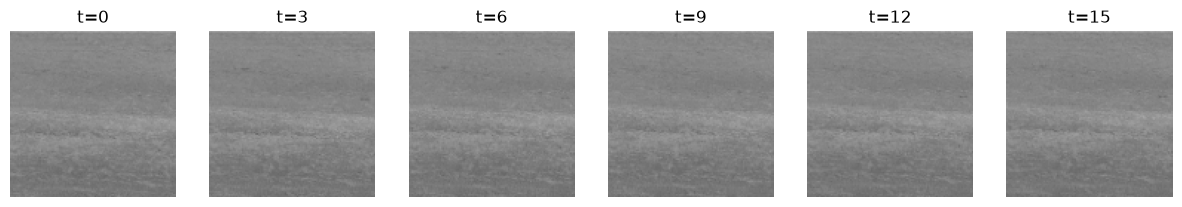

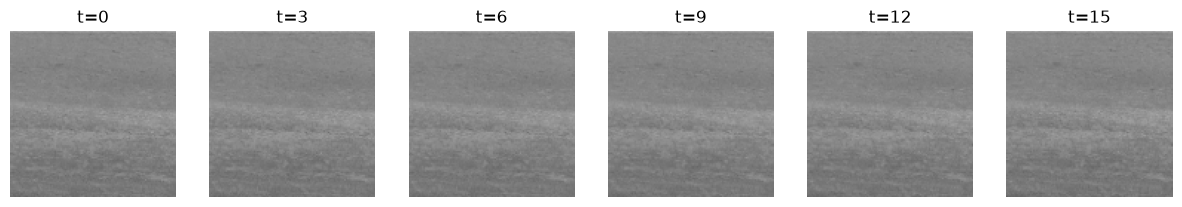

In [71]:
import matplotlib.pyplot as plt

walking_video = load_video_fixed_stride(
    train_samples[0]["path"],
    num_frames=16,
    stride=2
)

fig, axes = plt.subplots(1, 6, figsize=(15, 3))

indices = [0, 3, 6, 9, 12, 15]

for ax, idx in zip(axes, indices):
    frame = walking_video[idx].permute(1, 2, 0)
    ax.imshow(frame)
    ax.set_title(f"t={idx}")
    ax.axis("off")

plt.show()



running_video = load_video_fixed_stride(
    running_sample["path"],
    num_frames=16,
    stride=2
)

fig, axes = plt.subplots(1, 6, figsize=(15, 3))

indices = [0, 3, 6, 9, 12, 15]

for ax, idx in zip(axes, indices):
    frame = running_video[idx].permute(1, 2, 0)

    ax.imshow(frame)
    ax.set_title(f"t={idx}")
    ax.axis("off")

plt.show()



In [80]:
from pathlib import Path

sequence_file = Path("../data/00sequences.txt")
with open(sequence_file, "r") as f:
    lines = f.readlines()

    for i, line in enumerate(lines[:10]):
        if "person01" in line:
            print(i, repr(line.strip()))
            break
    start = i

    for j in range(13, 25):
        print(j, repr(lines[j].strip()))

    for i, line in enumerate(lines):
        if "person01_" in line:
            print("Trouvé à la ligne", i)
            print(repr(line.strip()))
            break

    for j in range(i, i + 8):
        print(j, repr(lines[j].strip()))

13 'In our experiments (Schuldt, Laptev and Caputo, ICPR 2004) we used the'
14 'following subdivision of sequences with respect to the subject:'
15 ''
16 'Training:   person11, 12, 13, 14, 15, 16, 17, 18'
17 'Validation: person19, 20, 21, 23, 24, 25, 01, 04'
18 'Test:       person22, 02, 03, 05, 06, 07, 08, 09, 10'
19 ''
20 ''
21 'person01_boxing_d1\t\tframes\t1-95, 96-185, 186-245, 246-360'
22 'person01_boxing_d2\t\tframes\t1-106, 107-195, 196-265, 305-390'
23 'person01_boxing_d3\t\tframes\t1-95, 96-230, 231-360, 361-465'
24 'person01_boxing_d4\t\tframes\t1-106, 107-170, 171-245, 246-370'
Trouvé à la ligne 21
'person01_boxing_d1\t\tframes\t1-95, 96-185, 186-245, 246-360'
21 'person01_boxing_d1\t\tframes\t1-95, 96-185, 186-245, 246-360'
22 'person01_boxing_d2\t\tframes\t1-106, 107-195, 196-265, 305-390'
23 'person01_boxing_d3\t\tframes\t1-95, 96-230, 231-360, 361-465'
24 'person01_boxing_d4\t\tframes\t1-106, 107-170, 171-245, 246-370'
25 'person01_handclapping_d1\tframes\t1-102, 103-18

In [84]:
line = lines[21].strip()
print(line)

left, right = line.split("frames")

print("LEFT :", repr(left))
print("RIGHT:", repr(right))

video_id = left.strip()
ranges_text = right.strip()

print(video_id)
print(ranges_text)

person01_boxing_d1		frames	1-95, 96-185, 186-245, 246-360
LEFT : 'person01_boxing_d1\t\t'
RIGHT: '\t1-95, 96-185, 186-245, 246-360'
person01_boxing_d1
1-95, 96-185, 186-245, 246-360


In [85]:
ranges = ranges_text.split(",")

print(ranges)

['1-95', ' 96-185', ' 186-245', ' 246-360']


In [86]:
sequences = []

for r in ranges:
    start, end = r.strip().split("-")

    start = int(start)
    end = int(end)

    sequences.append((start, end))

print(sequences)

[(1, 95), (96, 185), (186, 245), (246, 360)]


In [87]:
parts = video_id.split("_")
print(parts)

['person01', 'boxing', 'd1']


In [88]:
person = parts[0]
action = parts[1]
condition = parts[2]

print(person)
print(action)
print(condition)

person01
boxing
d1


In [90]:
samples_line = []

for start, end in sequences:
    sample = {
        "video_id": video_id,
        "person": person,
        "class_name": action,
        "start": start,
        "end": end
    }

    samples_line.append(sample)

print(samples_line)

[{'video_id': 'person01_boxing_d1', 'person': 'person01', 'class_name': 'boxing', 'start': 1, 'end': 95}, {'video_id': 'person01_boxing_d1', 'person': 'person01', 'class_name': 'boxing', 'start': 96, 'end': 185}, {'video_id': 'person01_boxing_d1', 'person': 'person01', 'class_name': 'boxing', 'start': 186, 'end': 245}, {'video_id': 'person01_boxing_d1', 'person': 'person01', 'class_name': 'boxing', 'start': 246, 'end': 360}]


In [98]:
sequence_samples = []

for line in lines:

    # ignorer les lignes qui ne sont pas des annotations
    if "frames" not in line:
        continue

    # 1. séparer la partie gauche et les intervalles
    left, right = line.split("frames")
    # 2. récupérer video_id
    video_id = left.strip()

    # 3. récupérer person et action
    parts = video_id.split("_")
    person = parts[0]
    action = parts[1]

    # 4. ignorer les actions qu'on n'a pas téléchargées
    if action not in class_to_idx:
        continue

    # 5. transformer les "1-95, 96-185..." en tuples
    ranges_text = right.strip()
    ranges = ranges_text.split(",")
    sequences = []

    for r in ranges:
        start, end = r.strip().split("-")

        start = int(start)
        end = int(end)

        sequences.append((start, end))

    # 6. créer un sample pour CHAQUE intervalle
    for start, end in sequences:
        sample = {
            "path": Path("../data/raw") / action / f"{video_id}_uncomp.avi",
            "video_id": video_id,
            "person": person,
            "class_name": action,
            "label": class_to_idx[action],
            "start": start,
            "end": end
        }

        sequence_samples.append(sample)

    

In [99]:
print("Nombre de séquences :", len(sequence_samples))

print(sequence_samples[0])
print(sequence_samples[-1])

Nombre de séquences : 1197
{'path': PosixPath('../data/raw/boxing/person01_boxing_d1_uncomp.avi'), 'video_id': 'person01_boxing_d1', 'person': 'person01', 'class_name': 'boxing', 'label': 2, 'start': 1, 'end': 95}
{'path': PosixPath('../data/raw/walking/person25_walking_d4_uncomp.avi'), 'video_id': 'person25_walking_d4', 'person': 'person25', 'class_name': 'walking', 'label': 0, 'start': 488, 'end': 592}


In [101]:
from collections import Counter

print(Counter(sample["class_name"] for sample in sequence_samples))
print(sequence_samples[0])
print(sequence_samples[0]["path"])
print(sequence_samples[0]["path"].exists())

Counter({'running': 400, 'walking': 400, 'boxing': 397})
{'path': PosixPath('../data/raw/boxing/person01_boxing_d1_uncomp.avi'), 'video_id': 'person01_boxing_d1', 'person': 'person01', 'class_name': 'boxing', 'label': 2, 'start': 1, 'end': 95}
../data/raw/boxing/person01_boxing_d1_uncomp.avi
True


In [ ]:
def load_sequence(sample, num_frames=16, size=(112, 112)):
    video_path = sample["path"]

    # KTH commence à 1, OpenCV à 0
    start_idx = sample["start"] - 1
    end_idx = sample["end"] - 1

    cap = cv2.VideoCapture(str(video_path))

    # on se place une seule fois au début de la sous-séquence
    cap.set(cv2.CAP_PROP_POS_FRAMES, start_idx)

    frames = []
    current_idx = start_idx

    while current_idx <= end_idx:
        ret, frame = cap.read()

        if not ret:
            break

        frames.append(frame)
        current_idx += 1

    cap.release()

    print("Frames lues :", len(frames))

In [103]:
load_sequence(sequence_samples[0])

Frames lues : 94


In [ ]:
sample = sequence_samples[0]

cap = cv2.VideoCapture(str(sample["path"]))

all_frames = []

while True:
    ret, frame = cap.read()

    if not ret:
        break

    all_frames.append(frame)

cap.release()

print("Frames vidéo complète :", len(all_frames))

start_idx = sample["start"] - 1
end_idx = sample["end"]

sequence_frames = all_frames[start_idx:end_idx]

print("Annotation :", sample["start"], "-", sample["end"])
print("Frames sous-séquence :", len(sequence_frames))

Frames vidéo complète : 360
Annotation : 1 - 95
Frames sous-séquence : 95


In [105]:
indices = np.linspace(
    0,
    len(sequence_frames) - 1,
    16,
    dtype=int
)

print(indices)

[ 0  6 12 18 25 31 37 43 50 56 62 68 75 81 87 94]


In [106]:
selected = []

for idx in indices:
    frame = sequence_frames[idx]

    frame = cv2.cvtColor(frame, cv2.COLOR_BGR2RGB)
    frame = cv2.resize(frame, (112, 112))

    frame = torch.from_numpy(frame).permute(2, 0, 1)

    selected.append(frame)

In [107]:
video_tensor = torch.stack(selected).float() / 255.0

print(video_tensor.shape)
print(video_tensor.dtype)
print(video_tensor.min(), video_tensor.max())

torch.Size([16, 3, 112, 112])
torch.float32
tensor(0.0667) tensor(0.9333)


In [ ]:
def load_sequence(sample, num_frames=16, size=(112, 112)):
    video_path = sample["path"]

    # KTH commence à 1, OpenCV à 0
    start_idx = sample["start"] - 1
    end_idx = sample["end"] - 1

    cap = cv2.VideoCapture(str(video_path))

    # on se place une seule fois au début de la sous-séquence
    cap.set(cv2.CAP_PROP_POS_FRAMES, start_idx)

    frames = []
    current_idx = start_idx

    while current_idx <= end_idx:
        ret, frame = cap.read()

        if not ret:
            break

        frames.append(frame)
        current_idx += 1

    cap.release()

    print("Frames lues :", len(frames))

In [108]:
def load_sequence(sample, num_frames=16, size=(112, 112)):
    # 1. lire toute la vidéo
    video_path = sample['path']

    # 2. récupérer start/end
    start = sample['start'] - 1
    end = sample['end']

    # 3. extraire uniquement la sous-séquence annotée
    cap = cv2.VideoCapture(str(video_path))
    all_frames = []

    while True:
        ret, frame = cap.read()

        if not ret:
            break

        all_frames.append(frame)

    cap.release()
    sequence_frames = all_frames[start:end]

    # 4. choisir num_frames indices avec np.linspace
    indices = np.linspace(
        0,
        len(sequence_frames) - 1,
        num_frames,
        dtype=int
    )

    selected = []

    for idx in indices:
        frame = sequence_frames[idx]

        frame = cv2.cvtColor(frame, cv2.COLOR_BGR2RGB)
        frame = cv2.resize(frame, size)

        frame = torch.from_numpy(frame).permute(2, 0, 1)

        selected.append(frame) 
    video_tensor = torch.stack(selected).float() / 255.0
    return video_tensor

In [109]:
video = load_sequence(sequence_samples[0])

print(video.shape)
print(video.dtype)
print(video.min(), video.max())

torch.Size([16, 3, 112, 112])
torch.float32
tensor(0.0667) tensor(0.9333)


In [110]:
train_people = {
    "person11", "person12", "person13", "person14",
    "person15", "person16", "person17", "person18"
}

val_people = {
    "person19", "person20", "person21", "person23",
    "person24", "person25", "person01", "person04"
}

test_people = {
    "person22", "person02", "person03", "person05",
    "person06", "person07", "person08", "person09",
    "person10"
}

In [111]:
train_sequences = [
    s for s in sequence_samples
    if s['person'] in train_people
]

val_sequences = [
    s for s in sequence_samples
    if s['person'] in val_people
]

test_sequences = [
    s for s in sequence_samples
    if s['person'] in test_people
]

print("Train :", len(train_sequences))
print("Val   :", len(val_sequences))
print("Test  :", len(test_sequences))
print(
    "Total :",
    len(train_sequences)
    + len(val_sequences)
    + len(test_sequences)
)

Train : 382
Val   : 384
Test  : 431
Total : 1197


In [112]:
from collections import Counter

print("Train :", Counter(s["class_name"] for s in train_sequences))
print("Val   :", Counter(s["class_name"] for s in val_sequences))
print("Test  :", Counter(s["class_name"] for s in test_sequences))

Train : Counter({'running': 128, 'walking': 128, 'boxing': 126})
Val   : Counter({'boxing': 128, 'running': 128, 'walking': 128})
Test  : Counter({'running': 144, 'walking': 144, 'boxing': 143})


In [113]:
class SequenceDataset(Dataset):

    def __init__(self, samples):
        self.samples = samples

    def __len__(self):
        return len(self.samples)

    def __getitem__(self, idx):
        sample = self.samples[idx]

        X = load_sequence(sample)
        y = sample['label']

        return X, y

In [114]:
train_dataset = SequenceDataset(train_sequences)

X, y = train_dataset[0]

print(X.shape)
print(y)

torch.Size([16, 3, 112, 112])
2


In [115]:
train_dataset = SequenceDataset(train_sequences)
val_dataset = SequenceDataset(val_sequences)
test_dataset = SequenceDataset(test_sequences)

In [116]:
from torch.utils.data import DataLoader

train_loader = DataLoader(
    train_dataset,
    batch_size=4,
    shuffle=True,
    num_workers=0
)

In [117]:
videos, labels = next(iter(train_loader))

print("Videos :", videos.shape)
print("Labels :", labels.shape)
print("Labels :", labels)

Videos : torch.Size([4, 16, 3, 112, 112])
Labels : torch.Size([4])
Labels : tensor([2, 2, 1, 1])


In [118]:
from pathlib import Path

PROCESSED_SEQUENCE_ROOT = Path("../data/processed_sequences")
PROCESSED_SEQUENCE_ROOT.mkdir(parents=True, exist_ok=True)

In [119]:
sample = sequence_samples[0]

filename = (
    f"{sample['video_id']}_"
    f"{sample['start']}_{sample['end']}.pt"
)

print(filename)

person01_boxing_d1_1_95.pt


In [120]:
video_tensor = load_sequence(sample)

output_path = PROCESSED_SEQUENCE_ROOT / filename

torch.save(video_tensor, output_path)

print(output_path)
print(output_path.exists())

../data/processed_sequences/person01_boxing_d1_1_95.pt
True


In [121]:
loaded = torch.load(output_path, weights_only=True)

print(loaded.shape)
print(torch.equal(video_tensor, loaded))

torch.Size([16, 3, 112, 112])
True


In [122]:
from collections import defaultdict

samples_by_video = defaultdict(list)

for sample in sequence_samples:
    samples_by_video[sample["path"]].append(sample)

print("Nombre d'AVI :", len(samples_by_video))

Nombre d'AVI : 300


In [123]:
video_path, video_samples = next(iter(samples_by_video.items()))

print(video_path)
print("Nombre de séquences :", len(video_samples))

for s in video_samples:
    print(s["start"], s["end"], s["class_name"])

../data/raw/boxing/person01_boxing_d1_uncomp.avi
Nombre de séquences : 4
1 95 boxing
96 185 boxing
186 245 boxing
246 360 boxing


In [124]:
from collections import defaultdict

samples_by_video = defaultdict(list)

for sample in sequence_samples:
    samples_by_video[sample["path"]].append(sample)

print("Nombre d'AVI :", len(samples_by_video))

Nombre d'AVI : 300


In [125]:
video_path, video_samples = next(iter(samples_by_video.items()))

print(video_path)
print("Nombre de séquences :", len(video_samples))

for s in video_samples:
    print(s["start"], s["end"], s["class_name"])

../data/raw/boxing/person01_boxing_d1_uncomp.avi
Nombre de séquences : 4
1 95 boxing
96 185 boxing
186 245 boxing
246 360 boxing


In [126]:
video_path, video_samples = next(iter(samples_by_video.items()))

In [127]:
cap = cv2.VideoCapture(str(video_path))

all_frames = []

while True:
    ret, frame = cap.read()

    if not ret:
        break

    all_frames.append(frame)

cap.release()

print("Frames vidéo :", len(all_frames))
print("Sous-séquences :", len(video_samples))

Frames vidéo : 360
Sous-séquences : 4


In [ ]:
from collections import defaultdict
from pathlib import Path

CACHE_DIR = Path("../data/processed_sequences")
CACHE_DIR.mkdir(parents=True, exist_ok=True)

samples_by_video = defaultdict(list)

for sample in sequence_samples:
    samples_by_video[sample["path"]].append(sample)

processed_samples = []

for video_idx, (video_path, video_samples) in enumerate(samples_by_video.items()):

    cap = cv2.VideoCapture(str(video_path))
    all_frames = []

    while True:
        ret, frame = cap.read()
        if not ret:
            break
        all_frames.append(frame)

    cap.release()

    for sample in video_samples:
        start = sample["start"] - 1
        end = sample["end"]

        sequence_frames = all_frames[start:end]

        indices = np.linspace(
            0,
            len(sequence_frames) - 1,
            16,
            dtype=int
        )

        selected = []

        for idx in indices:
            frame = sequence_frames[idx]
            frame = cv2.cvtColor(frame, cv2.COLOR_BGR2RGB)
            frame = cv2.resize(frame, (112, 112))
            frame = torch.from_numpy(frame).permute(2, 0, 1)

            selected.append(frame)

        tensor = torch.stack(selected).float() / 255.0

        filename = (
            f"{sample['video_id']}_"
            f"{sample['start']}_{sample['end']}.pt"
        )

        output_path = CACHE_DIR / filename
        torch.save(tensor, output_path)

        processed_sample = sample.copy()
        processed_sample["path"] = output_path

        processed_samples.append(processed_sample)

    if (video_idx + 1) % 25 == 0:
        print(f"{video_idx + 1}/{len(samples_by_video)} AVI traités")

print("Séquences préparées :", len(processed_samples))